Loaded: ../heart_hrv_cleaned.csv
Shape: (921, 85)
Unmapped rows: 0
After dropping unmapped rows, shape: (921, 86)
Numeric features count: 83

Top 20 important features (RF):
HRV_MCVNN           0.038080
HRV_IQRNN           0.031977
HRV_MadNN           0.031056
HRV_FuzzyEn         0.030164
HRV_MeanNN          0.028261
HRV_MedianNN        0.028238
HRV_MinNN           0.024970
HRV_KFD             0.024746
HRV_SD2a            0.024736
HRV_SDNNa           0.024480
HRV_CSI_Modified    0.024407
HRV_Prc20NN         0.024003
HRV_AI              0.023503
HRV_C2a             0.022755
HRV_Ca              0.022383
HRV_C1d             0.022119
HRV_Cd              0.022094
HRV_Prc80NN         0.022094
HRV_C1a             0.021885
HRV_SD2d            0.021353
dtype: float64

Selected top features (N=30):
['HRV_MCVNN', 'HRV_IQRNN', 'HRV_MadNN', 'HRV_FuzzyEn', 'HRV_MeanNN', 'HRV_MedianNN', 'HRV_MinNN', 'HRV_KFD', 'HRV_SD2a', 'HRV_SDNNa', 'HRV_CSI_Modified', 'HRV_Prc20NN', 'HRV_AI', 'HRV_C2a', 'HRV_Ca', 

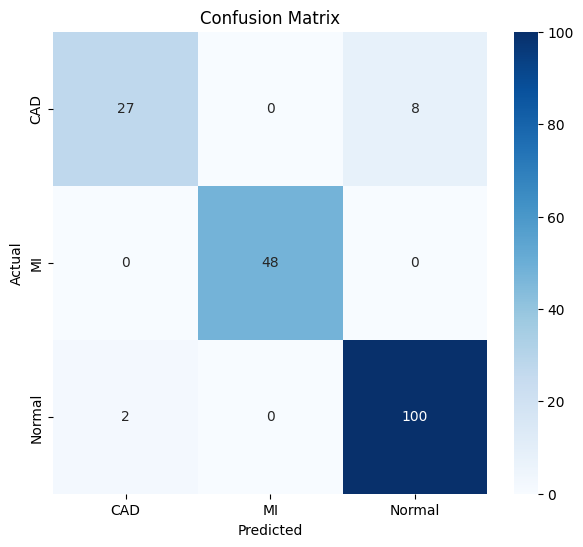

,CAD,MI,Normal
0,0.012873,0.082305,0.904822
1,0.022275,0.761897,0.215828
2,0.144581,0.061058,0.794361
3,0.582079,0.041728,0.376194
4,0.123551,0.084745,0.791703
5,0.095802,0.740857,0.163341
6,0.156281,0.104900,0.738819
7,0.587759,0.072710,0.339532



Fitting XGBoost separately for SHAP explainability...

Fitting XGBoost separately for SHAP explainability...
Preparing dataframes for SHAP (required for feature names)...
Computing SHAP values for multiclass XGBoost (this may take a moment)...


PermutationExplainer explainer: 186it [01:23,  1.96it/s]                                                               


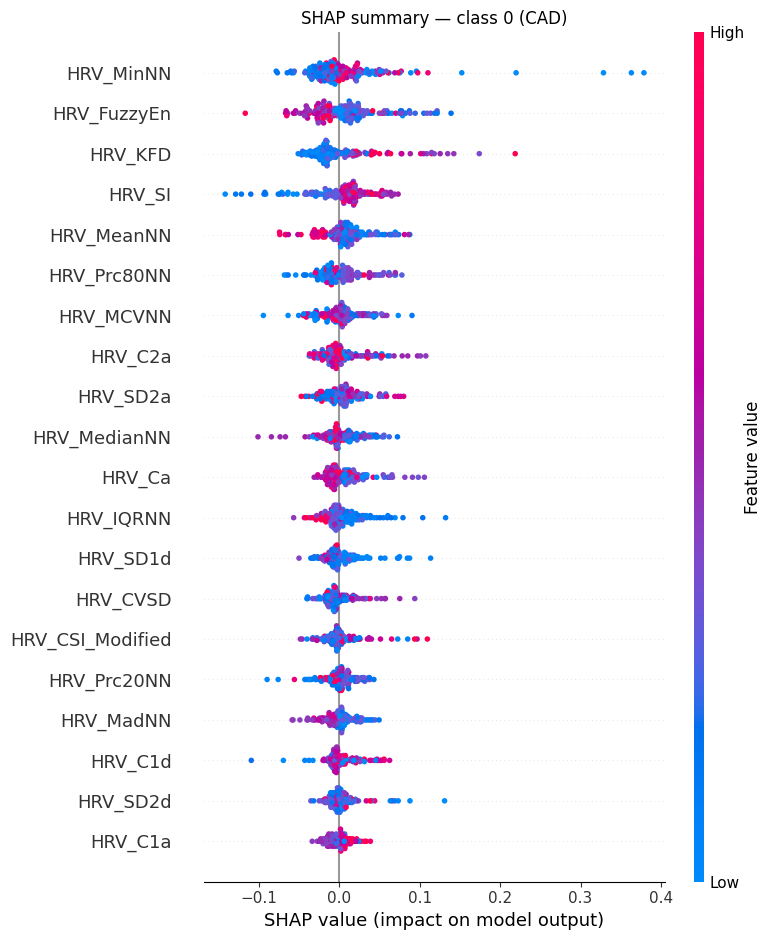

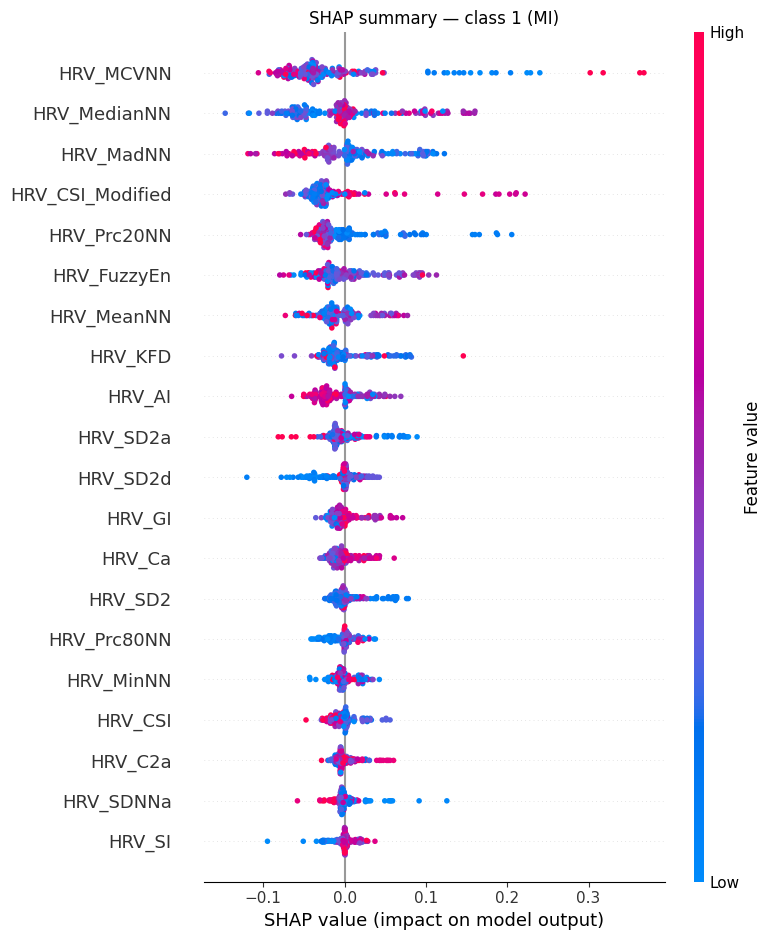

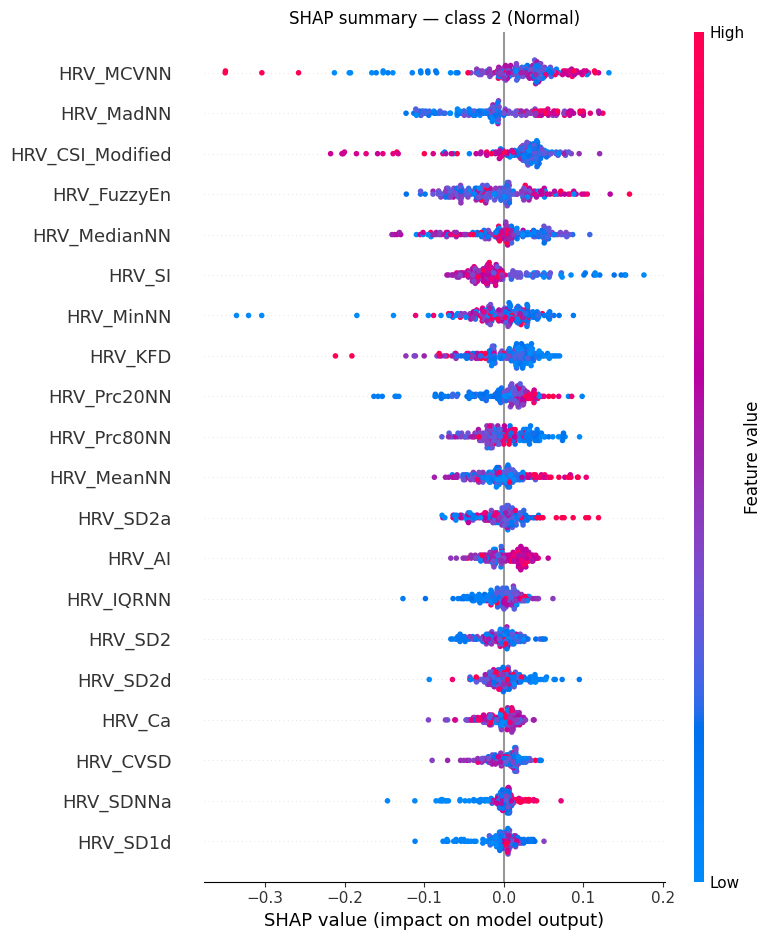

Computing SHAP values (may take a moment)...
Computing SHAP values for multiclass XGBoost...


PermutationExplainer explainer: 186it [01:31,  1.77it/s]                                                               


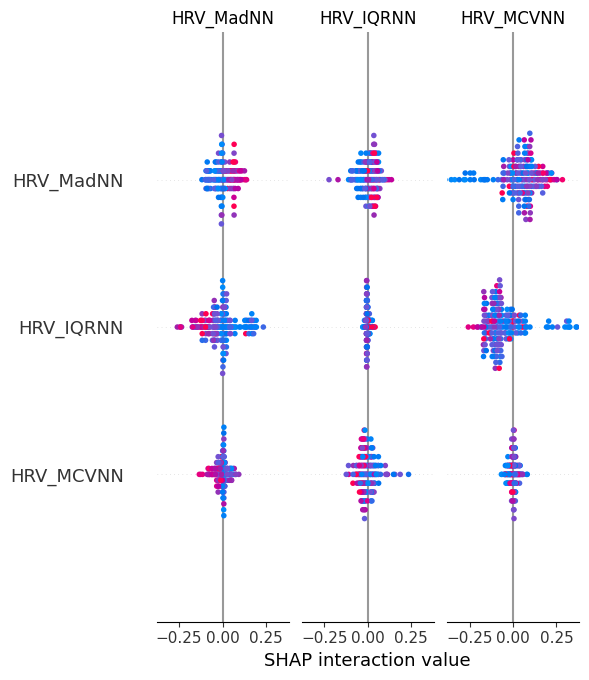

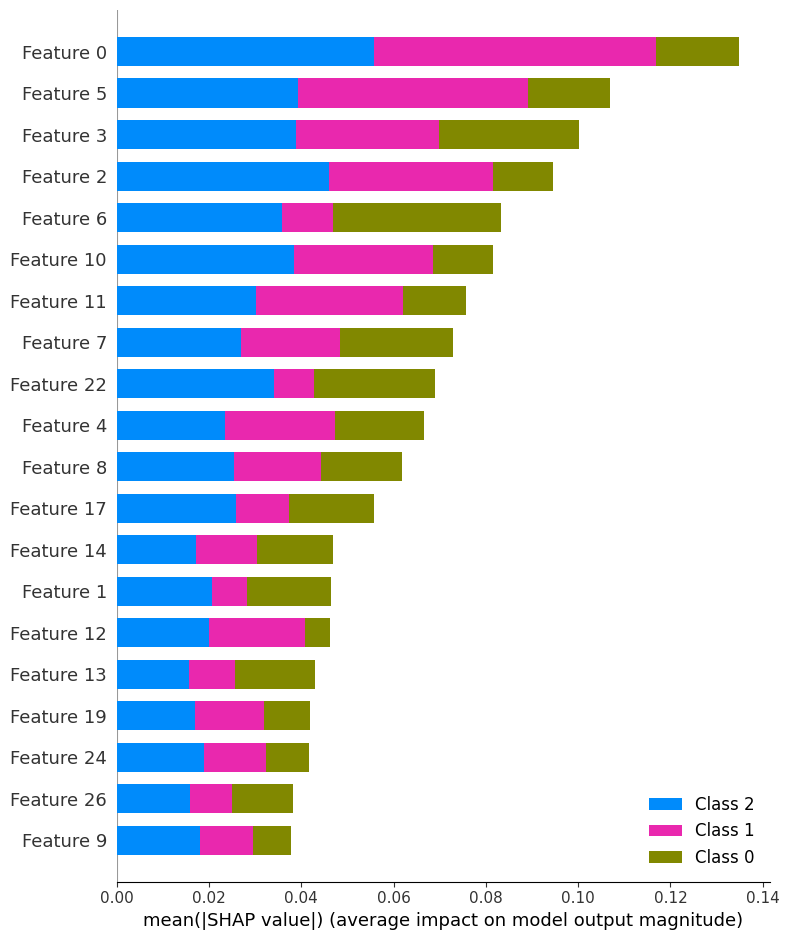


Saved models & artifacts to: model_output

Example prediction (using saved pipeline) -> {'pred_label': 'Normal', 'probs': {'CAD': np.float64(0.15818161654152987), 'MI': np.float64(0.05071115188085481), 'Normal': np.float64(0.791107246633997)}}


In [6]:
# =========================
# HRV → 4-class classifier (Normal, Arrhythmia, MI, CAD)
# - Loads cleaned HRV CSV
# - Maps existing dataset classes -> the 4 classes for Option A
# - Preprocess, select top features with RF importance
# - Train ensemble (XGBoost + RF + LR VotingClassifier)
# - Evaluate, print classification report & confusion matrix
# - Output per-sample class probabilities
# - SHAP explainability for XGBoost
# - Saves models and artifacts
# =========================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import shap
import joblib

# ---------- User-editable: path to your cleaned HRV CSV ----------
CSV_PATH = "../heart_hrv_cleaned.csv"   # change if your file is elsewhere
OUTPUT_DIR = "model_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---------- 1) Load data ----------
df = pd.read_csv(CSV_PATH)
print("Loaded:", CSV_PATH)
print("Shape:", df.shape)

# ---------- 2) Robustly map existing labels -> target 4 classes ----------
# Target classes we want:
target_classes = ["Normal", "Arrhythmia", "MI", "CAD"]

def infer_label_from_row(row):
    """
    Try to infer a target class from existing row fields.
    Priority:
      1) If 'label' column is a string like 'MI', 'Abnormal', 'History_MI', 'Normal'
      2) If 'image' path exists, inspect the folder name substring
      3) Fallback mapping if label is numeric using common mapping observed
    """
    # 1) check 'label' column (string)
    if 'label' in row and pd.notna(row['label']):
        lab = row['label']
        if isinstance(lab, str):
            lab_low = lab.strip().lower()
            if "normal" in lab_low:
                return "Normal"
            if "abnormal" in lab_low or "arrhythm" in lab_low or "arrhythmia" in lab_low or "abnorm" in lab_low:
                return "Arrhythmia"
            if "myocardial" in lab_low or "mi" == lab_low or "mi" in lab_low:
                # cover "MI" or "Myocardial Infarction"
                return "MI"
            if "history" in lab_low or "history_mi" in lab_low or "history-mi" in lab_low or "history of" in lab_low:
                return "CAD"
    # 2) inspect image path if present
    if 'image' in row and pd.notna(row['image']):
        img = str(row['image']).lower()
        if "normal" in img:
            return "Normal"
        if "abnormal" in img or "abnorm" in img:
            return "Arrhythmia"
        if "myocardial" in img or "/mi" in img or "\\mi" in img or "mi patients" in img:
            return "MI"
        if "history" in img or "history_mi" in img:
            return "CAD"
    # 3) fallback numeric mapping heuristic (observed in some runs)
    if 'label' in row and (isinstance(row['label'], (int, np.integer))):
        val = int(row['label'])
        # Common mapping from earlier conversation: {'Abnormal':0,'History_MI':1,'MI':2,'Normal':3}
        fallback_map = {0: "Arrhythmia", 1: "CAD", 2: "MI", 3: "Normal"}
        return fallback_map.get(val, None)
    return None

# Build new label column
df['target_label'] = df.apply(infer_label_from_row, axis=1)

# Check unmapped rows
n_unmapped = df['target_label'].isna().sum()
print("Unmapped rows:", n_unmapped)
if n_unmapped > 0:
    print("Showing sample unmapped rows (for manual inspection):")
    display(df[df['target_label'].isna()].head(10))

# Drop rows we couldn't map (if any)
df = df[df['target_label'].notna()].copy()
print("After dropping unmapped rows, shape:", df.shape)

# ---------- 3) Prepare features (X) and labels (y) ----------
# Drop non-feature columns like 'image' and previous 'label'
drop_cols = ['image', 'label'] if 'image' in df.columns else ['label']
X = df.drop(columns=[c for c in drop_cols if c in df.columns] + ['target_label'])
y = df['target_label'].copy()

# Keep only numeric features (HRV numeric columns)
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
X = X[numeric_cols]
print("Numeric features count:", len(numeric_cols))

# ---------- 4) Preprocessing pipeline ----------
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler', StandardScaler())
])
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols)
], remainder='drop')

X_pp = preprocessor.fit_transform(X)   # numpy array
X_pp_df = pd.DataFrame(X_pp, columns=numeric_cols)

# ---------- 5) Feature importance + selection (RandomForest) ----------
rf_sel = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_sel.fit(X_pp_df, y)  # y is string labels - RF supports that
importances = rf_sel.feature_importances_
feat_imp = pd.Series(importances, index=numeric_cols).sort_values(ascending=False)
print("\nTop 20 important features (RF):")
print(feat_imp.head(20))

# Choose top N features (tuneable)
TOP_N = 30
top_features = feat_imp.head(TOP_N).index.tolist()
print("\nSelected top features (N={}):\n{}".format(TOP_N, top_features))

# Reduce X to top features
X_sel = X_pp_df[top_features].values

# ---------- 6) Train/test split ----------
le = LabelEncoder()
y_enc = le.fit_transform(y)  # encode Normal/Arrhythmia/MI/CAD -> 0..3
print("Label encoding:", dict(zip(le.classes_, le.transform(le.classes_))))

X_train, X_test, y_train, y_test = train_test_split(
    X_sel, y_enc, test_size=0.2, stratify=y_enc, random_state=42
)

# ---------- 7) Train ensemble (XGB + RF + LR) ----------
xgb = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=5,
                    use_label_encoder=False, eval_metric='mlogloss', random_state=42, n_jobs=4)
rf2 = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
lr = LogisticRegression(max_iter=500, random_state=42)

voting = VotingClassifier(
    estimators=[('xgb', xgb), ('rf', rf2), ('lr', lr)],
    voting='soft',
    n_jobs=1         # keep 1 to avoid multiprocessing pickling issues on some systems
)

print("\nTraining voting ensemble (this may take a bit)...")
voting.fit(X_train, y_train)

# ---------- 8) Evaluate ----------
y_pred = voting.predict(X_test)
y_prob = voting.predict_proba(X_test)

print("\nAccuracy on test:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Show a few probability predictions (first 8)
prob_df = pd.DataFrame(y_prob, columns=le.classes_)
display(prob_df.head(8))

# ---------- 9) SHAP explainability for XGBoost ----------
# Train XGBoost individually (for SHAP) if not already fitted
print("\nFitting XGBoost separately for SHAP explainability...")
xgb.fit(X_train, y_train)
# ---------- 9) SHAP explainability for XGBoost (fixed) ----------
print("\nFitting XGBoost separately for SHAP explainability...")
xgb.fit(X_train, y_train)

print("Preparing dataframes for SHAP (required for feature names)...")
# X_train and X_test are numpy arrays with columns = top_features
X_train_df = pd.DataFrame(X_train, columns=top_features)
X_test_df  = pd.DataFrame(X_test,  columns=top_features)

feature_names = top_features  # now defined

print("Computing SHAP values for multiclass XGBoost (this may take a moment)...")

# 1) Create a prediction function wrapper for SHAP
def xgb_predict(X):
    # SHAP will pass in a numpy array or DataFrame; ensure predict_proba receives array
    return xgb.predict_proba(np.array(X))

# 2) Create SHAP explainer using the wrapper and a background/sample dataset
# Use a small background sample to speed things up (optional)
background = X_train_df.sample(min(200, len(X_train_df)), random_state=42)
explainer = shap.Explainer(xgb_predict, background)

# 3) Compute SHAP values on the test set
shap_values = explainer(X_test_df)   # an Explanation object

# shap_values.values shape for multiclass: (n_samples, n_features, n_classes)
vals = shap_values.values

# 4) Plot summary for each class separately
n_classes = vals.shape[2]
for class_idx in range(n_classes):
    plt.figure(figsize=(8,6))
    title = f"SHAP summary — class {class_idx} ({le.inverse_transform([class_idx])[0]})"
    shap.summary_plot(vals[:, :, class_idx], X_test_df, feature_names=feature_names, show=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Optional: global plot that aggregates (not always meaningful for multiclass)
# shap.summary_plot(vals.reshape(vals.shape[0]*vals.shape[1], -1), 
#                   np.repeat(X_test_df.values, n_classes, axis=0), feature_names=feature_names)

print("Computing SHAP values (may take a moment)...")


print("Computing SHAP values for multiclass XGBoost...")

# 1. Create a prediction function wrapper for SHAP
def xgb_predict(X):
    return xgb.predict_proba(X)

# 2. Create SHAP explainer using the wrapper
explainer = shap.Explainer(xgb_predict, X_train)

# 3. Compute SHAP values
shap_values = explainer(X_test)

# 4. Plot summary (for all classes combined)
shap.summary_plot(shap_values.values, X_test, feature_names=feature_names)



# Summary plot (multiclass)
# Use DataFrame for nice feature axis labels
shap.summary_plot(shap_values, pd.DataFrame(X_test, columns=top_features))

# ---------- 10) Save models and artifacts ----------
joblib.dump(voting, os.path.join(OUTPUT_DIR, "voting_ensemble.pkl"))
joblib.dump(xgb, os.path.join(OUTPUT_DIR, "xgb_for_shap.pkl"))
joblib.dump(preprocessor, os.path.join(OUTPUT_DIR, "preprocessor.pkl"))
joblib.dump(top_features, os.path.join(OUTPUT_DIR, "top_features.pkl"))
joblib.dump(le, os.path.join(OUTPUT_DIR, "label_encoder.pkl"))

print("\nSaved models & artifacts to:", OUTPUT_DIR)

# ---------- 11) Example: function to make prediction on a new HRV sample ----------
def predict_hrv_sample(sample_df):
    """
    sample_df: pd.DataFrame with same numeric feature columns as original (can contain more).
    Returns: dict with class probabilities and predicted label name.
    """
    # keep numeric columns and the top features only
    sample_num = sample_df[numeric_cols].copy()
    sample_pp = preprocessor.transform(sample_num)
    sample_pp_df = pd.DataFrame(sample_pp, columns=numeric_cols)
    sample_sel = sample_pp_df[top_features].values
    probs = voting.predict_proba(sample_sel)[0]
    pred_idx = np.argmax(probs)
    return {"pred_label": le.inverse_transform([pred_idx])[0],
            "probs": dict(zip(le.classes_, probs))}

# Example usage (first test row)
sample_row = pd.DataFrame([X.iloc[0].fillna(0).to_dict()])  # original first numeric row
res = predict_hrv_sample(sample_row)
print("\nExample prediction (using saved pipeline) ->", res)

# End of script
